In [33]:
# General Imports
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Building Model
from keras.utils import plot_model
from tensorflow.keras import models
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import legacy


# Training Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

# Model Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Data Processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import load_img

## Importing Data

In [34]:


# Download latest version
path = 'lungcancer'

print("Path to dataset files:", path)

Path to dataset files: lungcancer


In [35]:
import os

filename = 'lungcancer'
train_path = os.path.join(filename, 'Training')

# Collect only directories in 'classes'
classes = [sub_folder for sub_folder in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, sub_folder))]
print(classes)

img_list = []
label_list = []

['malignant', 'benign']


In [36]:
train_path='lungcancer/Training'
test_path='lungcancer/Testing'

In [37]:
img_list=[]
label_list=[]
for label in classes:
    for img_file in os.listdir(train_path+'/'+label):
        img_list.append(train_path+label+'/'+img_file)
        label_list.append(label)

In [38]:
train_data = pd.DataFrame({'Image':img_list,'Label':label_list})
train_data

,Image,Label
0,lungcancer/Trainingmalignant/129-001 (185).dcm...,malignant
1,lungcancer/Trainingmalignant/129-001 (61).dcm.png,malignant
2,lungcancer/Trainingmalignant/129-001 (184).dcm...,malignant
3,lungcancer/Trainingmalignant/164-001 (110).dcm...,malignant
4,lungcancer/Trainingmalignant/164-001 (111).dcm...,malignant
...,...,...
1318,lungcancer/Trainingbenign/28-001 (94).dcm.png,benign
1319,lungcancer/Trainingbenign/100-001 (35).dcm.png,benign
1320,lungcancer/Trainingbenign/100-001 (34).dcm.png,benign
1321,lungcancer/Trainingbenign/100-001 (4).dcm.png,benign


In [39]:
img_list=[]
label_list=[]
for label in classes:
    for img_file in os.listdir(test_path+'/'+label):
        img_list.append(test_path+'/'+label+'/'+img_file)
        label_list.append(label)

In [40]:
test_data = pd.DataFrame({'Image':img_list,'Label':label_list})
test_data

,Image,Label
0,lungcancer/Testing/malignant/129-001 (60).dcm.png,malignant
1,lungcancer/Testing/malignant/1-042.dcm.png,malignant
2,lungcancer/Testing/malignant/11-001 (45).dcm.png,malignant
3,lungcancer/Testing/malignant/11-001 (44).dcm.png,malignant
4,lungcancer/Testing/malignant/11-001 (113).dcm.png,malignant
...,...,...
408,lungcancer/Testing/benign/28-001 (38).dcm.png,benign
409,lungcancer/Testing/benign/189-001 (82).dcm.png,benign
410,lungcancer/Testing/benign/1-196.dcm.png,benign
411,lungcancer/Testing/benign/174-001 (44).dcm.png,benign


## Data Visualization

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt

def Plot_Classes(BASE_URL, Rows=2, Columns=5):
    plt.figure(figsize=(25, 8))
    image_count = 1

    for directory in os.listdir(BASE_URL):
        # Skip hidden files like .DS_Store
        if directory[0] != '.':
            dir_path = os.path.join(BASE_URL, directory)
            
            # Count files in the directory
            Max_Random = len(os.listdir(dir_path))
            Random_Number = np.random.randint(0, Max_Random)

            for i, file in enumerate(os.listdir(dir_path)):
                if i == Random_Number:
                    fig = plt.subplot(Rows, Columns, image_count)
                    image_count += 1

                    # Construct the full file path and read the image
                    img_path = os.path.join(dir_path, file)
                    image = plt.imread(img_path)
                    plt.imshow(image)
                    plt.title(directory)
                    break


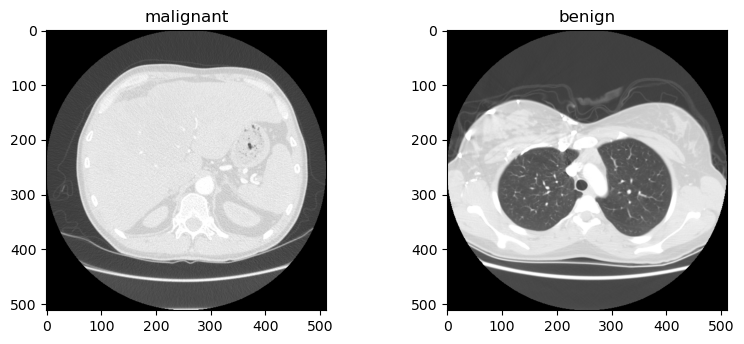

In [42]:
Plot_Classes(train_path)

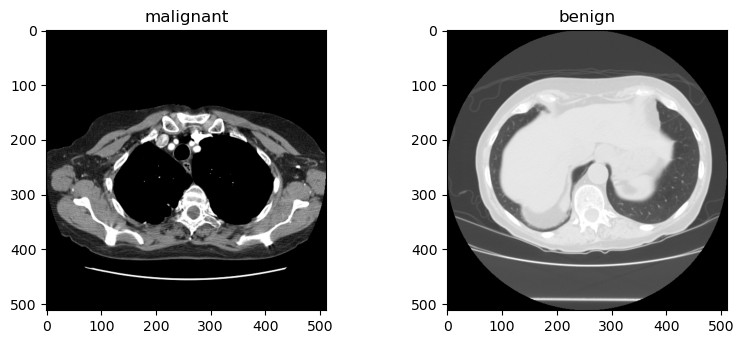

In [43]:
Plot_Classes(test_path)

In [44]:
train_data['Label'].value_counts()

Label
malignant    673
benign       650
Name: count, dtype: int64

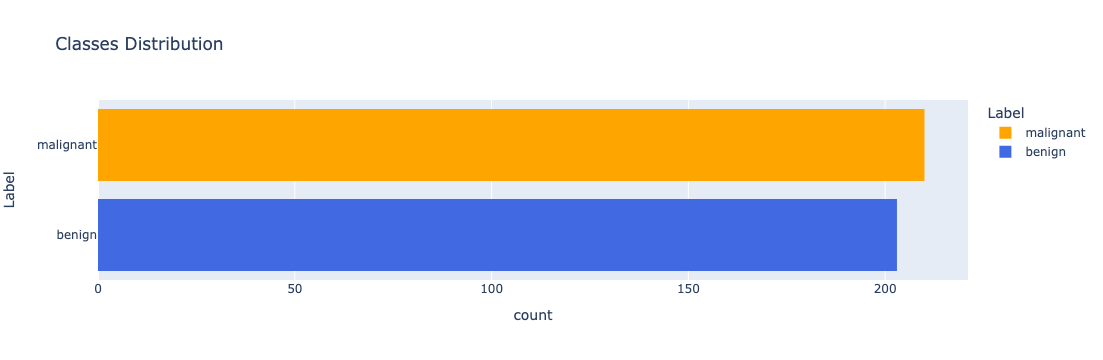

In [45]:
px.histogram(test_data, y="Label", color="Label", title="Classes Distribution", color_discrete_sequence=["#FFA500", "#4169E1","#FF0000","#808080"])

In [46]:
test_data['Label'].value_counts()

Label
malignant    210
benign       203
Name: count, dtype: int64

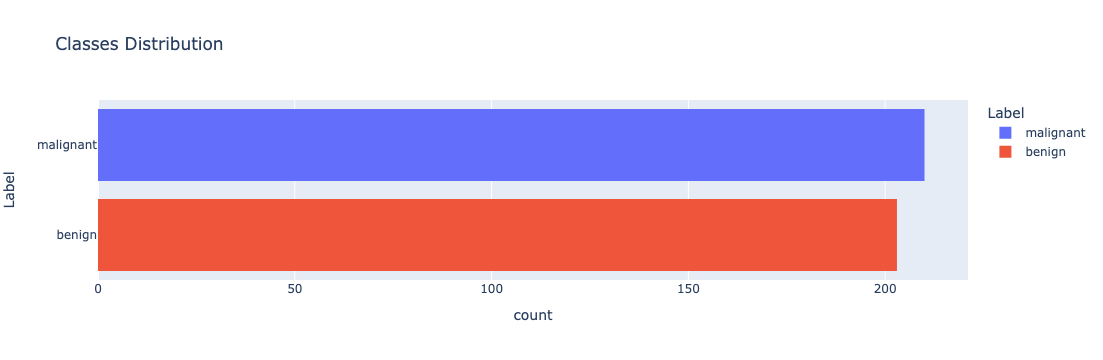

In [47]:
px.histogram(test_data, y="Label", color="Label", title="Classes Distribution")

## Data Preprocessing

In [48]:
# Image size
image_size = (150, 150)

# Training batch size
batch_size = 32

In [49]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.15, 
                                   rotation_range=10,
                                   brightness_range=(0.85, 1.15),
                                   width_shift_range=0.002,
                                   height_shift_range=0.002,
                                   shear_range=12.5,
                                   zoom_range=0,
                                   horizontal_flip=True,
                                   vertical_flip=False,
                                   fill_mode="nearest")

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.15)

# Creating training data generator
train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=image_size,
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    subset='training',  
                                                    seed=0)

# Creating validation data generator
val_generator = val_datagen.flow_from_directory(train_path,
                                                target_size=image_size,
                                                batch_size=batch_size,
                                                class_mode='categorical',
                                                subset='validation', 
                                                seed=0)

# No augmentation of the test data, just rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# applying the generator to testing data with constant seed
test_generator = test_datagen.flow_from_directory(test_path,
                                                  target_size=image_size,
                                                  batch_size=batch_size,
                                                  class_mode="categorical",
                                                  shuffle=False,
                                                  seed=0)

Found 1126 images belonging to 2 classes.
Found 197 images belonging to 2 classes.
Found 413 images belonging to 2 classes.


In [50]:
def show_ImageDataGenerator(ImageDataGenerator, num_samples=5, figsize=(12, 12), save=False):
    """
    Function to viusalize how the ImageDataGenerator augments the data
    """

    # Generate augmented samples
    # Use __next__() instead of next()
    augmented_samples = train_generator.__next__()

    # Extract images from the batch
    images = augmented_samples[0][:num_samples]

    # Display the augmented images
    fig, axes = plt.subplots(1, num_samples, figsize=figsize)

    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.axis('off')

    plt.tight_layout()

    if save:
        plt.savefig('show_ImageDataGenerator.pdf')

    plt.show()

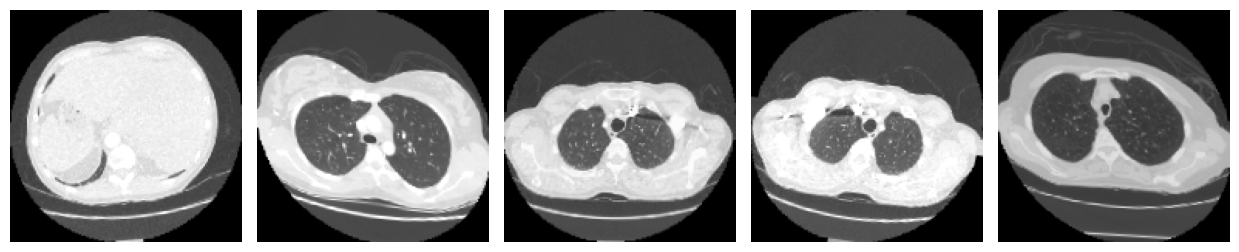

In [51]:
show_ImageDataGenerator(train_datagen, num_samples=5, figsize=(12.5, 8), save=False)

### Training Setup

In [52]:
# Image shape: height, width, RBG
image_shape = (image_size[0], image_size[1], 3)


print(f'Image shape: {image_shape}')
print(f'Batch size: {batch_size}')
print(f'Number of Train batches: {len(train_generator)}')
print(f'Number of Validation batches: {len(val_generator)}')
print(f'Number of Testing batches: {len(test_generator)}')

Image shape: (150, 150, 3)
Batch size: 32
Number of Train batches: 36
Number of Validation batches: 7
Number of Testing batches: 13


In [53]:
Classes_Map = train_generator.class_indices

num_classes = len(Classes_Map)

print("Number of Classes:", num_classes)
Classes_Map

Number of Classes: 2


{'benign': 0, 'malignant': 1}

In [54]:
def plot_curves(history):

  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  plt.figure(figsize=(15,5))
  plt.style.use('ggplot')


  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, 'bo-' , label = "TrainL oss")
  plt.plot(epochs, val_loss, 'o-' , color='orange', label = "Val Loss")
  plt.title("Loss")
  plt.xlabel("epochs")
  plt.legend()


  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, 'bo-' , label = "Train Acc")
  plt.plot(epochs, val_accuracy, 'o-' , color='orange' , label = "Val Acc")
  plt.title("Accuracy")
  plt.xlabel("epochs")
  plt.legend()

  plt.style.use('default')

In [55]:
def CM(model, test_generator, categories):
    """
    Function to return the confusion matrix of a given CNN model.
    """
    from sklearn.metrics import confusion_matrix
    # Predictions on test dataset
    predictions = model.predict(test_generator)
    predicted_categories = np.argmax(predictions, axis=1)
    true_categories = test_generator.classes

    # Create a confusion matrix
    confusion_matrix_array = confusion_matrix(true_categories, predicted_categories)
    print(f"Classification Report for {model}:")
    print(classification_report(true_categories, predicted_categories, target_names=categories))

    return confusion_matrix_array


def calculate_metrics(confusion_matrix, categories):
    """
    Function to calculate important metrics for multi-classification problems.
    """
    # Calculating 4 different metrics
    precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
    recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    f1_score = 2 * (precision * recall) / (precision + recall)
    accuracy = np.sum(np.diag(confusion_matrix)) / np.sum(confusion_matrix)

    # Printing the results based on each category
    for i, category in enumerate(categories):
        print(f"Class: {category.title()}")
        print(f"Precision: {precision[i]:.3f}")
        print(f"Recall: {recall[i]:.3f}")
        print(f"F1-Score: {f1_score[i]:.3f}\n")

    # Showing the total accuracy of the model
    print(f"\nAccuracy: {accuracy:.3f}")

## CNN Model

In [24]:
def create_cnn_model(input_shape=image_shape, num_classes=num_classes):
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,634 (13.17 MB)

 Trainable params: 3,453,634 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
cnn_history = cnn_model.fit(train_generator,epochs=100,validation_data=val_generator)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 315ms/step - accuracy: 0.5499 - loss: 0.7189 - val_accuracy: 1.0000 - val_loss: 0.1930
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.7438 - loss: 0.4755 - val_accuracy: 1.0000 - val_loss: 0.3119
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.7432 - loss: 0.4670 - val_accuracy: 0.9949 - val_loss: 0.1886
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.8025 - loss: 0.4191 - val_accuracy: 0.7970 - val_loss: 0.3112
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 316ms/step - accuracy: 0.8341 - loss: 0.3602 - val_accuracy: 0.7056 - val_loss: 0.7773
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 324ms/step - accuracy: 0.8508 - loss: 0.3038 - val_accuracy: 0.7157 - val_loss: 1.0303
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 336ms/step - accuracy: 0.8604 - loss: 0.2924 - val_accuracy: 0.5939 - val_loss: 1.3960
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 330ms/step - accuracy: 0.8678 - loss: 0.2688 - 

### CNN Model Evaluation

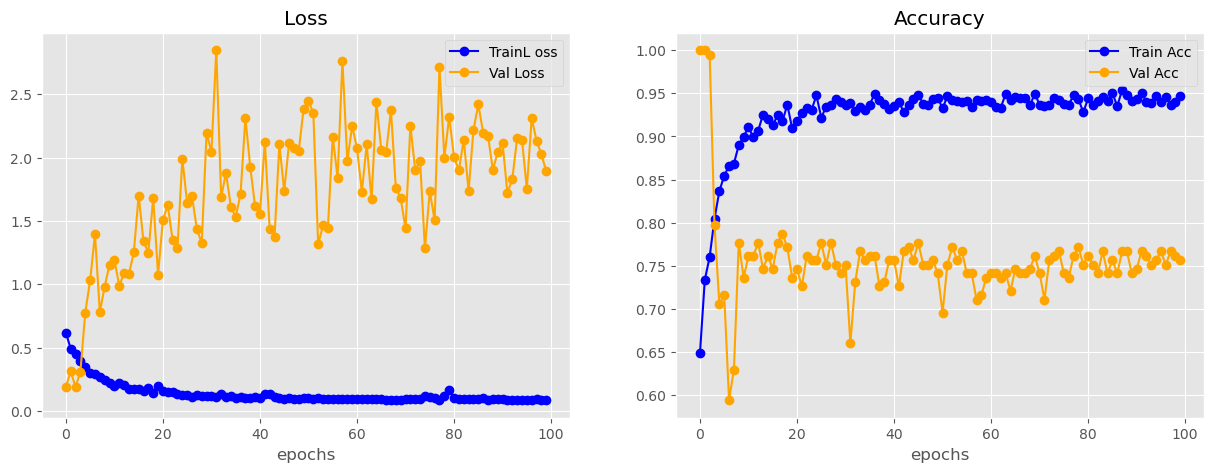

In [26]:
plot_curves(cnn_history)

In [27]:
loss, accuracy = cnn_model.evaluate(test_generator)
print(f"Test Loss: {loss:0.5f}")
print(f"Test Accuracy: {accuracy:0.5f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9226 - loss: 0.3379
Test Loss: 0.44878
Test Accuracy: 0.90799


In [28]:
import joblib

In [29]:
joblib.dump(cnn_model, 'cnn_lung.joblib')

['cnn_lung.joblib']

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
Classification Report for <Sequential name=sequential, built=True>:
              precision    recall  f1-score   support

   malignant       0.89      0.93      0.91       203
      benign       0.93      0.89      0.91       210

    accuracy                           0.91       413
   macro avg       0.91      0.91      0.91       413
weighted avg       0.91      0.91      0.91       413



ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

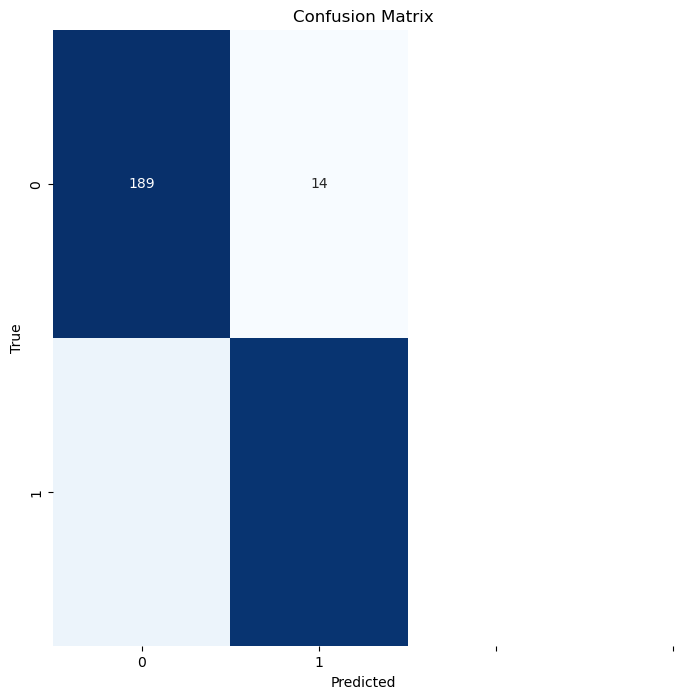

In [30]:
# Plotting confusion matrix
confusion_matrix = CM(model=cnn_model, test_generator=test_generator, categories=classes)

plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], ha='center')
plt.yticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], va='center')
plt.show()

## VGG16 Model

In [56]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


for layer in base_model_vgg.layers[:-10]:
    layer.trainable = False

for layer in base_model_vgg.layers[-10:]:
    layer.trainable = True

# Add custom classification head
x = base_model_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)  

model_vgg = Model(inputs=base_model_vgg.input, outputs=output)

model_vgg.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model_vgg.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,978,370 (57.14 MB)

 Trainable params: 13,832,962 (52.77 MB)

 Non-trainable params: 1,145,408 (4.37 MB)

In [57]:
vgg_history = model_vgg.fit(train_generator,epochs=50,validation_data=val_generator)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.6102 - loss: 0.6801 - val_accuracy: 0.7614 - val_loss: 0.3018
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.8467 - loss: 0.3611 - val_accuracy: 0.7462 - val_loss: 0.3495
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 164s 5s/step - accuracy: 0.8477 - loss: 0.3258 - val_accuracy: 0.6447 - val_loss: 0.9589
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 173s 5s/step - accuracy: 0.9024 - loss: 0.2209 - val_accuracy: 0.7310 - val_loss: 0.6208
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 177s 5s/step - accuracy: 0.8884 - loss: 0.2394 - val_accuracy: 0.6751 - val_loss: 1.0868
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.9477 - loss: 0.1188 - val_accuracy: 0.6701 - val_loss: 1.4870
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.9444 - loss: 0.1270 - val_accuracy: 0.7360 - val_loss: 0.4966
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 190s 5s/step - accuracy: 0.9292 - loss: 0.1496 - val_accuracy: 0.5990 - v

### VGG16 Model Evaluation

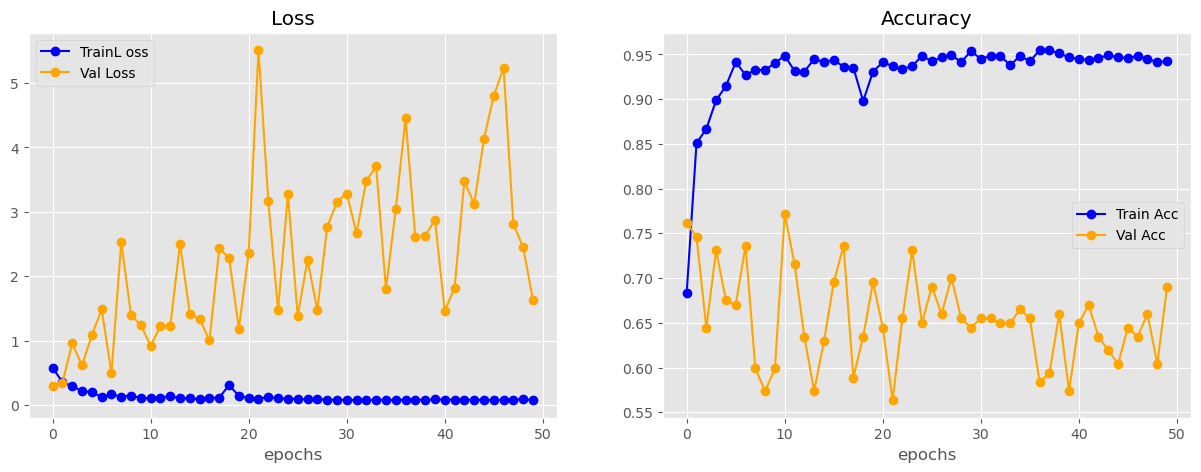

In [58]:
plot_curves(vgg_history)

In [59]:
loss, accuracy = model_vgg.evaluate(test_generator)
print(f"Test Loss: {loss:0.5f}")
print(f"Test Accuracy: {accuracy:0.5f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9285 - loss: 0.2581
Test Loss: 0.34714
Test Accuracy: 0.90799


In [60]:
joblib.dump(model_vgg, 'vgg16_lung.joblib')

['vgg16_lung.joblib']

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
Classification Report for <Functional name=functional_15, built=True>:
              precision    recall  f1-score   support

   malignant       0.87      0.95      0.91       203
      benign       0.95      0.87      0.91       210

    accuracy                           0.91       413
   macro avg       0.91      0.91      0.91       413
weighted avg       0.91      0.91      0.91       413



ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

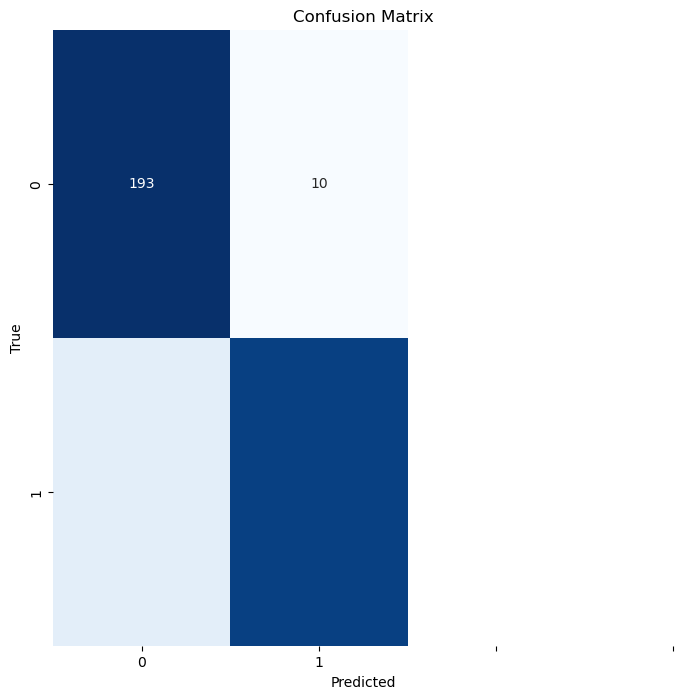

In [61]:
# Plotting confusion matrix
confusion_matrix = CM(model=model_vgg, test_generator=test_generator, categories=classes)

plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], ha='center')
plt.yticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], va='center')
plt.show()

## ResNet101 Model

In [62]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


base_model_resnet = ResNet101(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


# for layer in base_model_resnet.layers[:-10]:
#     layer.trainable = False

# for layer in base_model_resnet.layers[-10:]:
#     layer.trainable = True
    

# Add custom classification head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)  

model_resnet = Model(inputs=base_model_resnet.input, outputs=output)

model_resnet.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model_resnet.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 43,708,290 (166.73 MB)

 Trainable params: 43,602,946 (166.33 MB)

 Non-trainable params: 105,344 (411.50 KB)

In [63]:
resnet_history = model_resnet.fit(train_generator,epochs=50,validation_data=val_generator)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.7274 - loss: 0.5684 - val_accuracy: 0.4924 - val_loss: 2.2473
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.9215 - loss: 0.1686 - val_accuracy: 0.4924 - val_loss: 2.8508
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 164s 5s/step - accuracy: 0.9373 - loss: 0.1204 - val_accuracy: 0.4924 - val_loss: 1.5373
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 167s 5s/step - accuracy: 0.9427 - loss: 0.1010 - val_accuracy: 0.4924 - val_loss: 1.1785
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 171s 5s/step - accuracy: 0.9403 - loss: 0.0968 - val_accuracy: 0.4924 - val_loss: 3.6537
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 174s 5s/step - accuracy: 0.9202 - loss: 0.1314 - val_accuracy: 0.4924 - val_loss: 3.4806
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 175s 5s/step - accuracy: 0.9312 - loss: 0.1097 - val_accuracy: 0.4010 - val_loss: 1.1152
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 171s 5s/step - accuracy: 0.9346 - loss: 0.1188 - val_accuracy: 0.4924 - v

### ResNet101 Model Evaluation

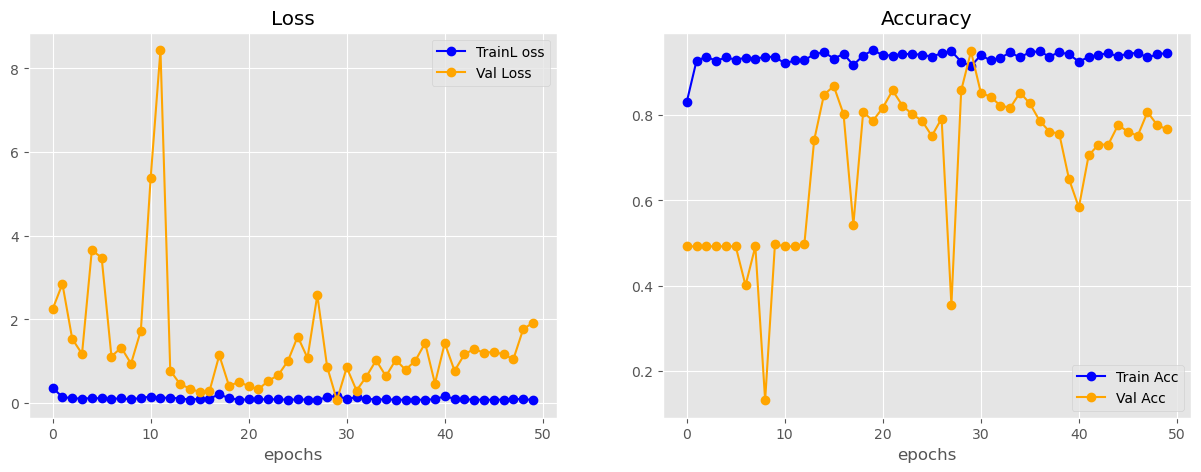

In [64]:
plot_curves(resnet_history)

In [65]:
loss, accuracy = model_resnet.evaluate(test_generator)
print(f"Test Loss: {loss:0.5f}")
print(f"Test Accuracy: {accuracy:0.5f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 806ms/step - accuracy: 0.9240 - loss: 0.2788
Test Loss: 0.37843
Test Accuracy: 0.91041


In [66]:
joblib.dump(model_resnet, 'resnet_lung.joblib')

['resnet_lung.joblib']

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 806ms/step
Classification Report for <Functional name=functional_17, built=True>:
              precision    recall  f1-score   support

   malignant       0.89      0.93      0.91       203
      benign       0.93      0.89      0.91       210

    accuracy                           0.91       413
   macro avg       0.91      0.91      0.91       413
weighted avg       0.91      0.91      0.91       413



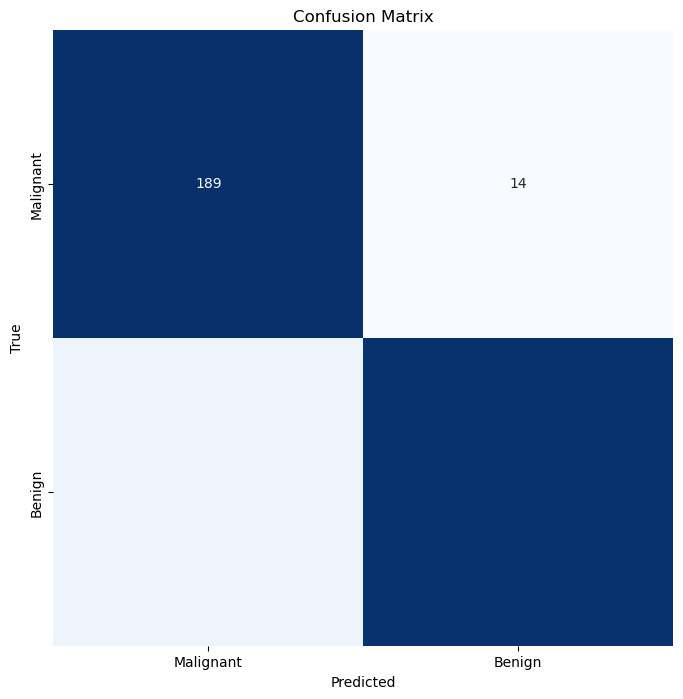

In [68]:
# Plotting confusion matrix
confusion_matrix = CM(model=model_resnet, test_generator=test_generator, categories=classes)

plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(2) + 0.5,
           labels=[name.title() for name in classes], ha='center')
plt.yticks(ticks=np.arange(2) + 0.5,
           labels=[name.title() for name in classes], va='center')
plt.show()

{'malignant': 0.0, 'benign': 100.0}
{'malignant': 0.0, 'benign': 100.0}
{'malignant': 25.477, 'benign': 74.523}
{'malignant': 0.0, 'benign': 100.0}
{'malignant': 0.0, 'benign': 100.0}
{'malignant': 0.0, 'benign': 100.0}
{'malignant': 0.0, 'benign': 100.0}
{'malignant': 49.947, 'benign': 50.053}
{'malignant': 0.0, 'benign': 100.0}
{'malignant': 0.002, 'benign': 99.998}


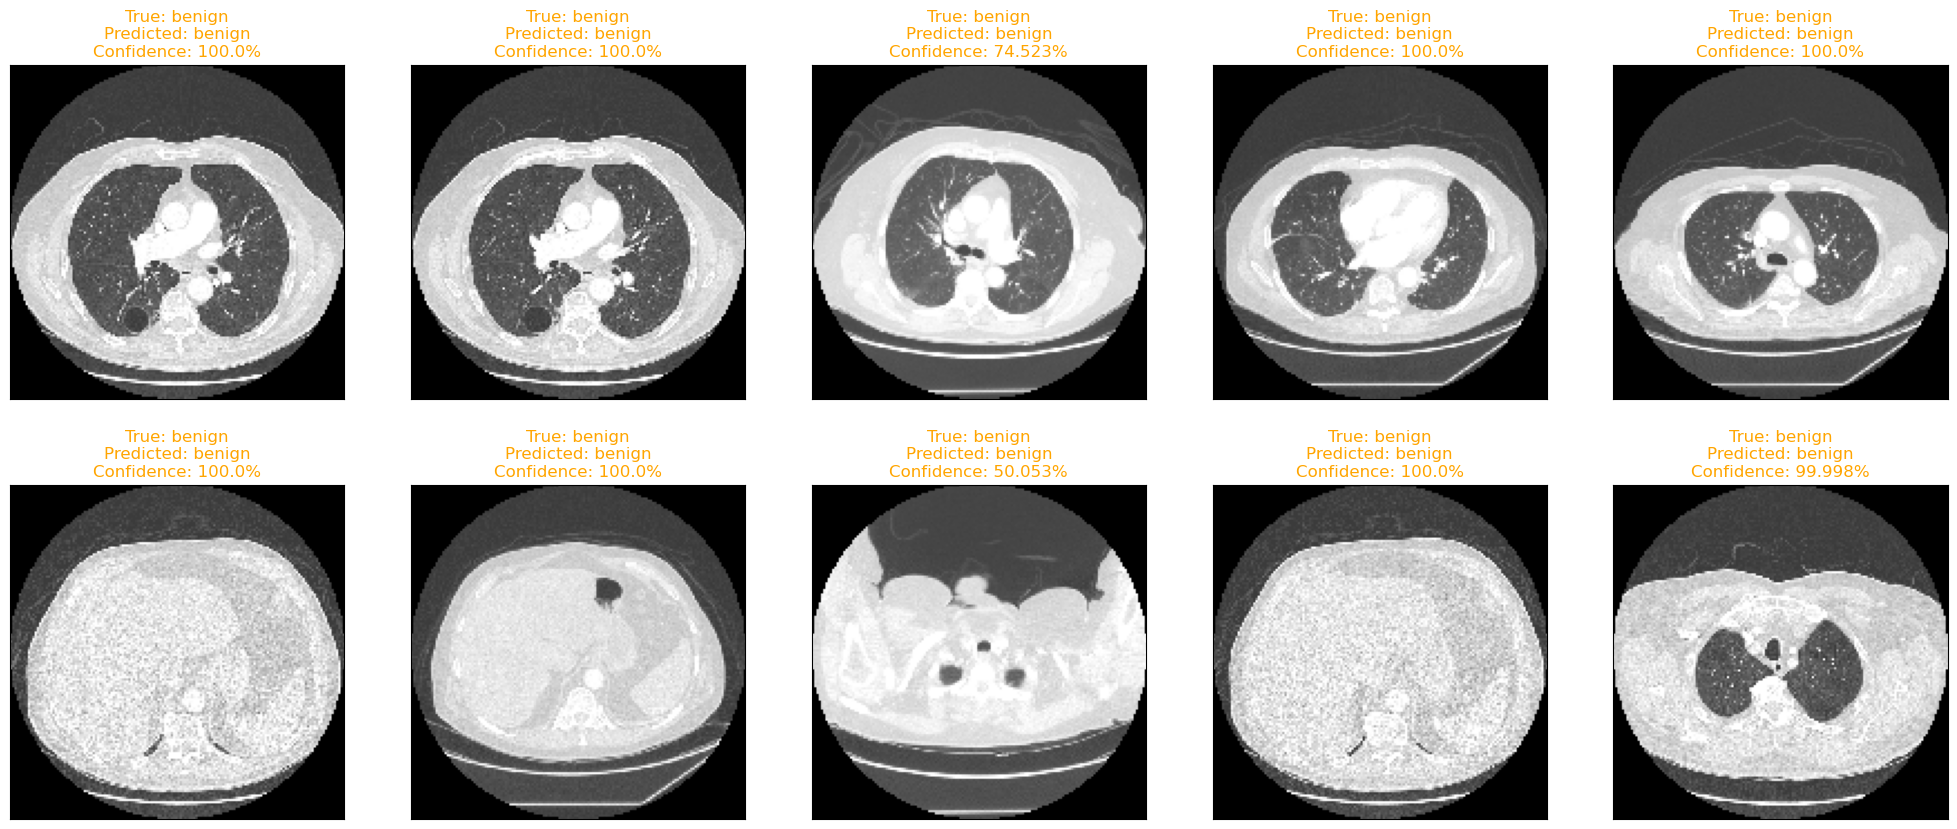

<Figure size 640x480 with 0 Axes>

In [70]:
# Display 10 random pictures predictions from the dataset with their labels

Random_batch = np.random.randint(0, len(test_generator))

Random_Img_Index = np.random.randint(0, batch_size , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    Model_Predictions = model_resnet.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0)

    Model_Highest_Prediction = np.argmax(Model_Predictions)

    Model_Predictions_Map = { c: round(p*100,3) for (c,p) in zip (classes, Model_Predictions.tolist()[0] ) }

    ax.imshow(Random_Img)

    Pred_Class = classes[Model_Highest_Prediction]

    if classes[Random_Img_Label] == Pred_Class:
      color = "orange"
    else:
      color = "red"
    ax.set_title(f"True: {classes[Random_Img_Label]}\nPredicted: {Pred_Class}\nConfidence: {Model_Predictions_Map[Pred_Class]}%",
          color=color)
    print(Model_Predictions_Map)
plt.show()
plt.tight_layout()